# 09 — Error Analysis

Looking at where and why each model fails. The main thing I want to understand is the 1,403 fraud cases that all three models missed simultaneously. Are there common patterns in those transactions that might explain why nothing caught them?

**Steps:**
1. Load models and generate predictions
2. Basic error counts (TP/FP/TN/FN)
3. False negative analysis: transaction amount
4. Deep dive: the 1,403 shared false negatives
5. False positive analysis
6. Model comparison

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf
import warnings
warnings.filterwarnings('ignore')

## 1. Load Models and Data

In [2]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

rf = joblib.load('../results/rf_model.pkl')
xgb = joblib.load('../results/xgb_model.pkl')
ae = tf.keras.models.load_model('../results/ae_model.keras')
scaler = joblib.load('../results/ae_scaler.pkl')
best_threshold = np.load('../results/ae_best_threshold.npy')

X_test_scaled = scaler.transform(X_test)

print(f'Test set: {X_test.shape} | Fraud cases: {y_test.sum()}')

Test set: (88581, 421) | Fraud cases: 3099


## 2. Generate Predictions

In [3]:
# RF predictions
rf_pred = rf.predict(X_test)

# XGBoost predictions
xgb_pred = xgb.predict(X_test)

# Autoencoder predictions
ae_recon = ae.predict(X_test_scaled, verbose=0)
ae_errors = np.mean(np.power(X_test_scaled - ae_recon, 2), axis=1)
ae_pred = (ae_errors > best_threshold).astype(int)

# Build a results dataframe
results = X_test.copy()
results['true'] = y_test.values
results['rf_pred'] = rf_pred
results['xgb_pred'] = xgb_pred
results['ae_pred'] = ae_pred
results['ae_error'] = ae_errors

print('Predictions generated.')

Predictions generated.


In [4]:
# Error type counts per model
for model in ['rf', 'xgb', 'ae']:
    pred_col = f'{model}_pred'
    fn = ((results['true'] == 1) & (results[pred_col] == 0)).sum()
    fp = ((results['true'] == 0) & (results[pred_col] == 1)).sum()
    tp = ((results['true'] == 1) & (results[pred_col] == 1)).sum()
    tn = ((results['true'] == 0) & (results[pred_col] == 0)).sum()
    print(f'{model.upper():>10} | TP: {tp:4d} | FP: {fp:4d} | TN: {tn:6d} | FN: {fn:4d}')

        RF | TP: 1363 | FP:  131 | TN:  85351 | FN: 1736
       XGB | TP: 1524 | FP:  158 | TN:  85324 | FN: 1575
        AE | TP: 1008 | FP: 2588 | TN:  82894 | FN: 2091


## 3. Analyse False Negatives (Missed Fraud)

False negatives are the most costly error in fraud detection, these are real fraud cases that the model missed.

In [5]:
# False negatives per model
rf_fn = results[(results['true'] == 1) & (results['rf_pred'] == 0)]
xgb_fn = results[(results['true'] == 1) & (results['xgb_pred'] == 0)]
ae_fn = results[(results['true'] == 1) & (results['ae_pred'] == 0)]

print(f'RF  — False Negatives: {len(rf_fn)}')
print(f'XGB — False Negatives: {len(xgb_fn)}')
print(f'AE  — False Negatives: {len(ae_fn)}')

RF  — False Negatives: 1736
XGB — False Negatives: 1575
AE  — False Negatives: 2091


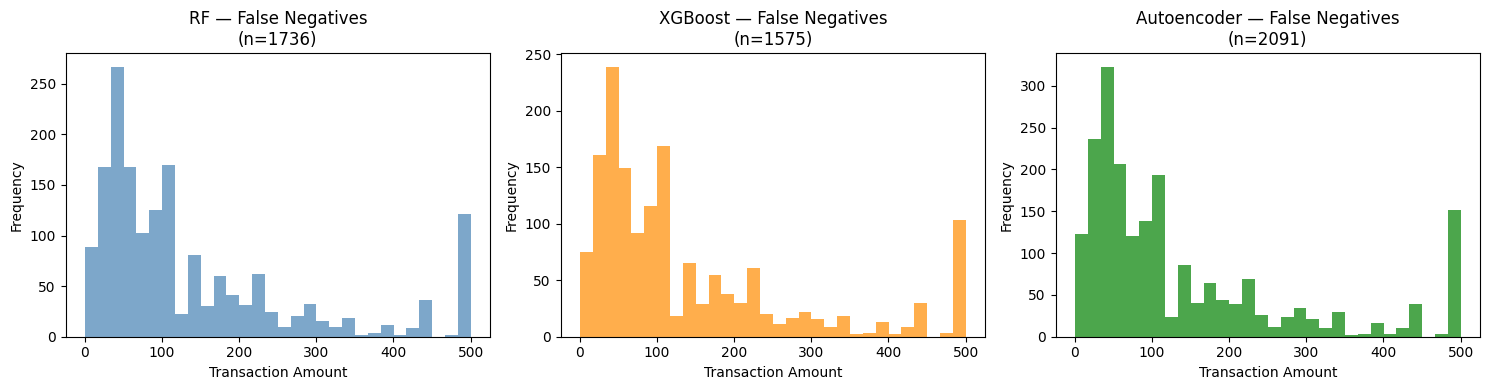

In [6]:
# Transaction amount distribution for false negatives
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, fn_df, label, color in zip(
    axes,
    [rf_fn, xgb_fn, ae_fn],
    ['RF', 'XGBoost', 'Autoencoder'],
    ['steelblue', 'darkorange', 'green']
):
    fn_df['TransactionAmt'].clip(upper=500).plot(
        kind='hist', bins=30, ax=ax, color=color, alpha=0.7
    )
    ax.set_title(f'{label} — False Negatives\n(n={len(fn_df)})')
    ax.set_xlabel('Transaction Amount')

plt.tight_layout()
plt.savefig('../results/figures/false_negatives_amt.png', dpi=150)
plt.show()

In [7]:
# How many fraud cases did ALL models miss?
all_miss = results[
    (results['true'] == 1) &
    (results['rf_pred'] == 0) &
    (results['xgb_pred'] == 0) &
    (results['ae_pred'] == 0)
]
print(f'Fraud cases missed by ALL three models: {len(all_miss)}')
print(f'Transaction amount stats for these cases:')
print(all_miss['TransactionAmt'].describe().round(2))

Fraud cases missed by ALL three models: 1403
Transaction amount stats for these cases:
count    1403.00
mean      169.72
std       229.49
min         0.47
25%        49.00
50%       100.00
75%       200.00
max      2161.00
Name: TransactionAmt, dtype: float64


## Deep dive: the shared false negatives

These 1,403 cases are the most interesting failures. All three models missed them despite using completely different approaches. If there are common patterns, it tells us something about what kind of fraud is genuinely hard to detect, not just where one model fell short.

In [8]:
# 10 randomly sampled shared FN cases
sample_fn = all_miss.sample(10, random_state=42)
print('10 randomly sampled shared false negatives:')
print(sample_fn[['TransactionAmt', 'true', 'rf_pred', 'xgb_pred', 'ae_pred']].to_string())

10 randomly sampled shared false negatives:
       TransactionAmt  true  rf_pred  xgb_pred  ae_pred
70322         107.950     1        0         0        0
58405         186.000     1        0         0        0
3224           42.559     1        0         0        0
80037         150.000     1        0         0        0
44393         335.000     1        0         0        0
21201          26.706     1        0         0        0
52176          53.950     1        0         0        0
62956         209.950     1        0         0        0
21319          92.000     1        0         0        0
19142          40.454     1        0         0        0


In [9]:
# categorical distributions: all fraud vs shared FNs
all_fraud = results[results['true'] == 1]

cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'DeviceType']
cat_cols = [c for c in cat_cols if c in results.columns]

print('Categorical feature distributions: all fraud vs shared FNs')
print('=' * 60)
for col in cat_cols:
    all_dist = all_fraud[col].value_counts(normalize=True).head(5)
    fn_dist  = all_miss[col].value_counts(normalize=True).head(5)
    combined = pd.DataFrame({
        'all_fraud_%': (all_dist * 100).round(1),
        'shared_FN_%': (fn_dist * 100).round(1)
    })
    print(f'\n{col}:')
    print(combined.to_string())

Categorical feature distributions: all fraud vs shared FNs

ProductCD:
   all_fraud_%  shared_FN_%
4         44.0         68.3
0         37.8         20.2
1          8.3          6.1
2          6.6          3.6
3          3.3          1.9

card4:
   all_fraud_%  shared_FN_%
3         65.0         65.7
2         31.5         30.2
1          2.5          3.4
0          0.9          0.6

card6:
   all_fraud_%  shared_FN_%
2         50.8         62.2
1         49.2         37.8

P_emaildomain:
    all_fraud_%  shared_FN_%
1           3.8          3.4
2           3.0          4.1
16         62.4         61.0
19         11.3          8.6
53         10.9         14.8

R_emaildomain:
    all_fraud_%  shared_FN_%
16         79.5         87.0
19         10.1          6.6
54          3.0          2.3
1           2.7          1.5
35          1.9          0.7

DeviceType:
   all_fraud_%  shared_FN_%
0         73.0         86.7
1         27.0         13.3


In [10]:
# transaction amount: all fraud vs shared FNs
print('TransactionAmt — all fraud:')
print(all_fraud['TransactionAmt'].describe().round(2))
print()
print('TransactionAmt — shared FNs:')
print(all_miss['TransactionAmt'].describe().round(2))
print()

# low-value transactions
low_fraud = (all_fraud['TransactionAmt'] < 50).mean()
low_fn    = (all_miss['TransactionAmt'] < 50).mean()
print(f'Proportion under $50:')
print(f'  all fraud   : {low_fraud:.2%}')
print(f'  shared FNs  : {low_fn:.2%}')

TransactionAmt — all fraud:
count    3099.00
mean      147.47
std       221.73
min         0.47
25%        35.97
50%        77.00
75%       168.00
max      3191.00
Name: TransactionAmt, dtype: float64

TransactionAmt — shared FNs:
count    1403.00
mean      169.72
std       229.49
min         0.47
25%        49.00
50%       100.00
75%       200.00
max      2161.00
Name: TransactionAmt, dtype: float64

Proportion under $50:
  all fraud   : 35.56%
  shared FNs  : 26.80%


In [11]:
# C-feature and M-feature comparison
c_cols = [c for c in results.columns if c.startswith('C') and c[1:].isdigit()]
m_cols = [c for c in results.columns if c.startswith('M')]

print('C-feature means: all fraud vs shared FNs')
c_compare = pd.DataFrame({
    'all_fraud': all_fraud[c_cols].mean(),
    'shared_FN': all_miss[c_cols].mean()
}).round(2)
print(c_compare.to_string())
print()
print('M-feature mode comparison:')
for col in m_cols:
    if col in results.columns:
        af_mode = all_fraud[col].mode()[0] if len(all_fraud[col].dropna()) > 0 else 'N/A'
        fn_mode = all_miss[col].mode()[0]  if len(all_miss[col].dropna()) > 0  else 'N/A'
        print(f'  {col}: all_fraud={af_mode}, shared_FN={fn_mode}')

C-feature means: all fraud vs shared FNs
     all_fraud  shared_FN
C1       34.62      15.57
C2       43.09      17.86
C3        0.00       0.00
C4       14.52       6.14
C5        1.61       2.33
C6       16.42       8.68
C7       12.50       6.01
C8       21.33       9.36
C9        1.83       2.45
C10      19.83       9.42
C11      23.19      11.19
C12      18.98       8.51
C13      25.93      20.72
C14      10.36       6.75

M-feature mode comparison:
  M1: all_fraud=1, shared_FN=1
  M2: all_fraud=1, shared_FN=1
  M3: all_fraud=1, shared_FN=1
  M4: all_fraud=0, shared_FN=0
  M5: all_fraud=0, shared_FN=0
  M6: all_fraud=0, shared_FN=0
  M7: all_fraud=0, shared_FN=0
  M8: all_fraud=0, shared_FN=0
  M9: all_fraud=1, shared_FN=1


In [12]:
# XGBoost SHAP for shared FNs: what was the model seeing?
import shap

fn_features = X_test.loc[all_miss.index].reset_index(drop=True).iloc[:50]

xgb_exp  = shap.TreeExplainer(xgb)
fn_shap  = xgb_exp.shap_values(fn_features, check_additivity=False)
if isinstance(fn_shap, list): fn_shap = fn_shap[1]

fn_shap_mean = pd.Series(fn_shap.mean(axis=0), index=fn_features.columns)

print('Features pushing TOWARD fraud (positive SHAP) for shared FNs:')
print(fn_shap_mean.nlargest(15).round(4))
print()
print('Features pushing AWAY from fraud (negative SHAP) for shared FNs:')
print(fn_shap_mean.nsmallest(15).round(4))

Features pushing TOWARD fraud (positive SHAP) for shared FNs:
D4                0.0370
TransactionAmt    0.0363
card6             0.0343
V97               0.0287
id_04             0.0253
card2             0.0243
V102              0.0186
M5                0.0168
V302              0.0162
TransactionDT     0.0161
D2                0.0158
card4             0.0135
C5                0.0120
V285              0.0117
card1             0.0111
dtype: float32

Features pushing AWAY from fraud (negative SHAP) for shared FNs:
V294    -0.2274
V258    -0.1986
C11     -0.1730
C1      -0.1542
V306    -0.1320
C12     -0.1228
V308    -0.1184
C6      -0.1067
V126    -0.0973
V288    -0.0915
V257    -0.0744
V317    -0.0715
V128    -0.0706
card5   -0.0660
C2      -0.0605
dtype: float32


In [13]:
# compare FN shap vs TP shap: where does XGBoost behave differently?
xgb_tp      = results[(results['true'] == 1) & (results['xgb_pred'] == 1)]
tp_features = X_test.loc[xgb_tp.index].reset_index(drop=True).iloc[:50]

tp_shap = xgb_exp.shap_values(tp_features, check_additivity=False)
if isinstance(tp_shap, list): tp_shap = tp_shap[1]
tp_shap_mean = pd.Series(tp_shap.mean(axis=0), index=tp_features.columns)

shap_diff = (tp_shap_mean - fn_shap_mean).abs().nlargest(15)
print('Features where XGBoost differs most between FNs and TPs:')
print(pd.DataFrame({
    'FN_mean_shap': fn_shap_mean[shap_diff.index].round(4),
    'TP_mean_shap': tp_shap_mean[shap_diff.index].round(4),
    'diff':         shap_diff.round(4)
}).to_string())

Features where XGBoost differs most between FNs and TPs:
       FN_mean_shap  TP_mean_shap    diff
C1          -0.1542        0.3147  0.4688
V258        -0.1986        0.1547  0.3534
C11         -0.1730        0.1716  0.3447
C12         -0.1228        0.1086  0.2314
C14         -0.0120        0.2098  0.2218
V257        -0.0744        0.1161  0.1905
card6        0.0343        0.2054  0.1711
V317        -0.0715        0.0624  0.1338
C6          -0.1067        0.0122  0.1190
M6          -0.0458        0.0677  0.1135
V156        -0.0057        0.1055  0.1112
V187        -0.0344        0.0666  0.1010
V90         -0.0006        0.0960  0.0967
V308        -0.1184       -0.0217  0.0966
V294        -0.2274       -0.1333  0.0941


## Summary of shared FN patterns

Key questions:
- Are shared FNs concentrated in certain product categories or card types?
- Do they have systematically different values on the C-features XGBoost normally relies on?
- What does the SHAP FN vs TP comparison suggest about why these cases looked legitimate to the model?

## 4. Analyse False Positives (Legitimate Flagged as Fraud)

False positives create unnecessary friction for legitimate customers and increase investigation costs.

In [14]:
rf_fp = results[(results['true'] == 0) & (results['rf_pred'] == 1)]
xgb_fp = results[(results['true'] == 0) & (results['xgb_pred'] == 1)]
ae_fp = results[(results['true'] == 0) & (results['ae_pred'] == 1)]

print(f'RF  — False Positives: {len(rf_fp)}')
print(f'XGB — False Positives: {len(xgb_fp)}')
print(f'AE  — False Positives: {len(ae_fp)}')

RF  — False Positives: 131
XGB — False Positives: 158
AE  — False Positives: 2588


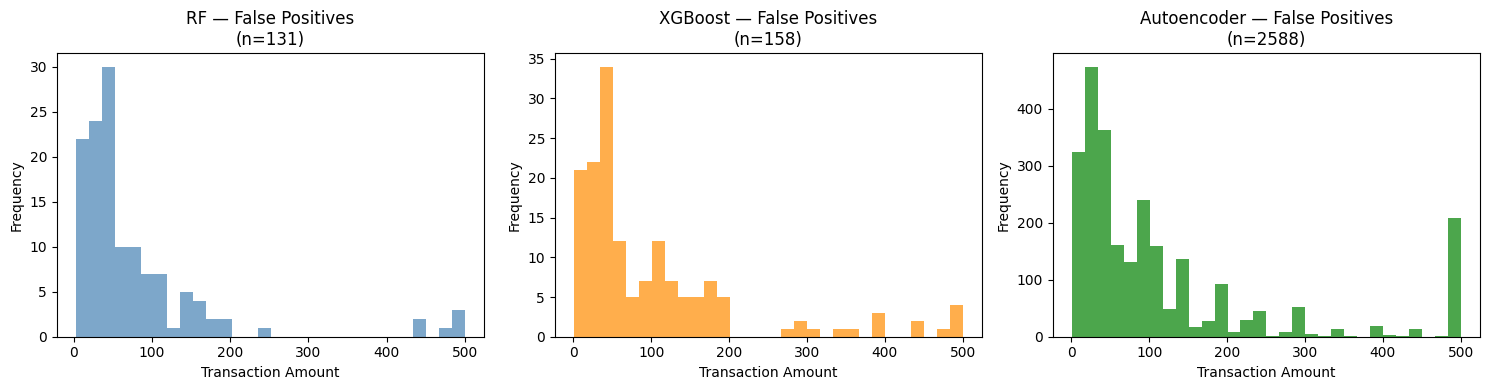

In [15]:
# Transaction amount for false positives
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, fp_df, label, color in zip(
    axes,
    [rf_fp, xgb_fp, ae_fp],
    ['RF', 'XGBoost', 'Autoencoder'],
    ['steelblue', 'darkorange', 'green']
):
    fp_df['TransactionAmt'].clip(upper=500).plot(
        kind='hist', bins=30, ax=ax, color=color, alpha=0.7
    )
    ax.set_title(f'{label} — False Positives\n(n={len(fp_df)})')
    ax.set_xlabel('Transaction Amount')

plt.tight_layout()
plt.savefig('../results/figures/false_positives_amt.png', dpi=150)
plt.show()

## 5. Compare Error Patterns Across Models

In [16]:
# Fraud cases caught by XGBoost but missed by Autoencoder
xgb_only = results[
    (results['true'] == 1) &
    (results['xgb_pred'] == 1) &
    (results['ae_pred'] == 0)
]

# Fraud cases caught by Autoencoder but missed by XGBoost
ae_only = results[
    (results['true'] == 1) &
    (results['ae_pred'] == 1) &
    (results['xgb_pred'] == 0)
]

print(f'Fraud caught by XGBoost only (AE missed): {len(xgb_only)}')
print(f'Fraud caught by AE only (XGBoost missed): {len(ae_only)}')

Fraud caught by XGBoost only (AE missed): 603
Fraud caught by AE only (XGBoost missed): 87


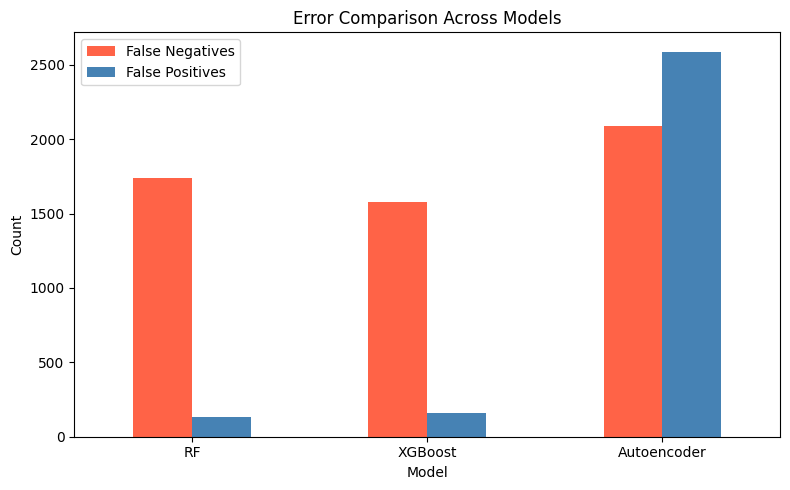

      Model  False Negatives  False Positives
         RF             1736              131
    XGBoost             1575              158
Autoencoder             2091             2588


In [17]:
# Summary bar chart
error_summary = pd.DataFrame({
    'Model': ['RF', 'XGBoost', 'Autoencoder'],
    'False Negatives': [len(rf_fn), len(xgb_fn), len(ae_fn)],
    'False Positives': [len(rf_fp), len(xgb_fp), len(ae_fp)]
})

error_summary.set_index('Model').plot(
    kind='bar', figsize=(8, 5),
    color=['tomato', 'steelblue']
)
plt.title('Error Comparison Across Models')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/figures/error_comparison.png', dpi=150)
plt.show()

print(error_summary.to_string(index=False))

In [18]:
# Save error results
error_summary.to_csv('../results/error_summary.csv', index=False)
print('Error summary saved.')

Error summary saved.
